# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

Размер датасета: (400, 64, 64)
Количество классов: 40


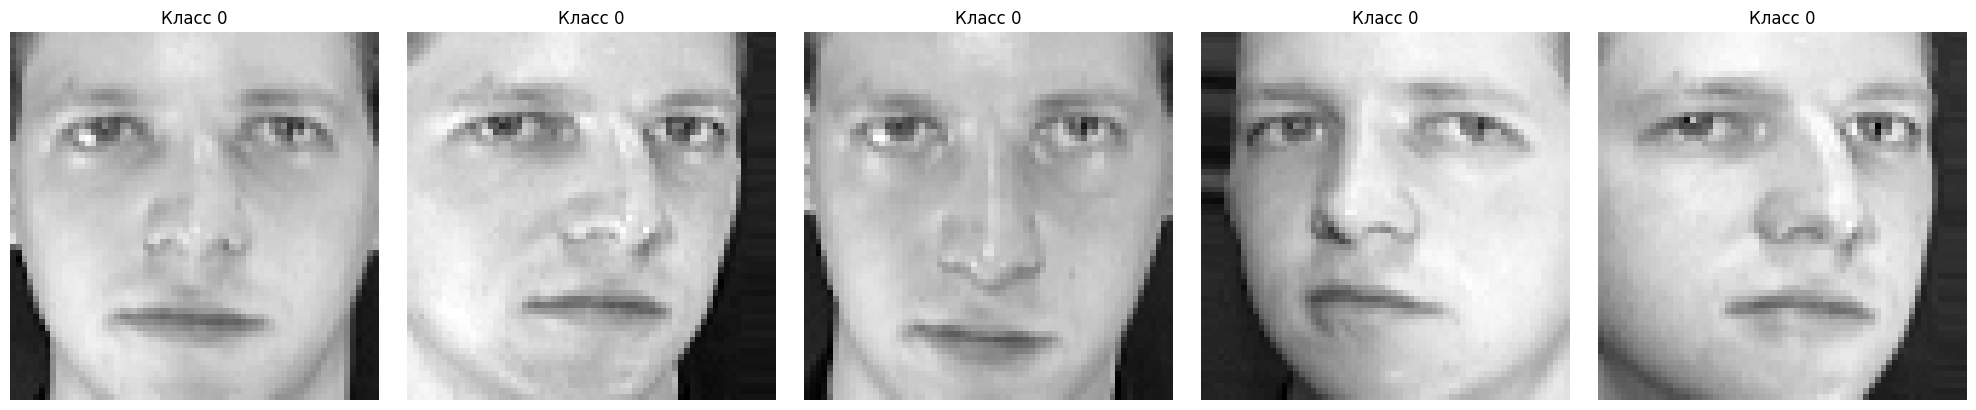

In [3]:
!pip install -q catboost lightgbm xgboost

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
# Загрузка датасета
faces = fetch_olivetti_faces()

X = faces.images
y = faces.target

print("Размер датасета:", X.shape)
print("Количество классов:", len(np.unique(y)))

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = faces.images[i]
    label = faces.target[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
X = X.reshape((X.shape[0], -1))

# нормализация
X = X / 255.0

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (300, 4096)
Test: (100, 4096)


In [5]:
models = {
    "CatBoost": CatBoostClassifier(
        iterations=20,
        depth=4,
        learning_rate=0.1,
        verbose=0),

    "LightGBM": LGBMClassifier(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=4),

    "XGBoost": XGBClassifier(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=4,
        eval_metric='mlogloss',
        verbosity=0),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=20)
}

results = []


Модель: CatBoost
Accuracy: 0.7400
Время обучения: 87.37 сек

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       0.00      0.00      0.00         3
           4       0.50      0.50      0.50         2
           5       0.75      1.00      0.86         3
           6       1.00      0.50      0.67         2
           7       0.60      1.00      0.75         3
           8       0.67      1.00      0.80         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      0.67      0.80         3
          12       1.00      1.00      1.00         2
          13       0.40      1.00      0.57         2
          14       0.75      1.00      0.86         3
          15       0.50      0.50      0.50       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


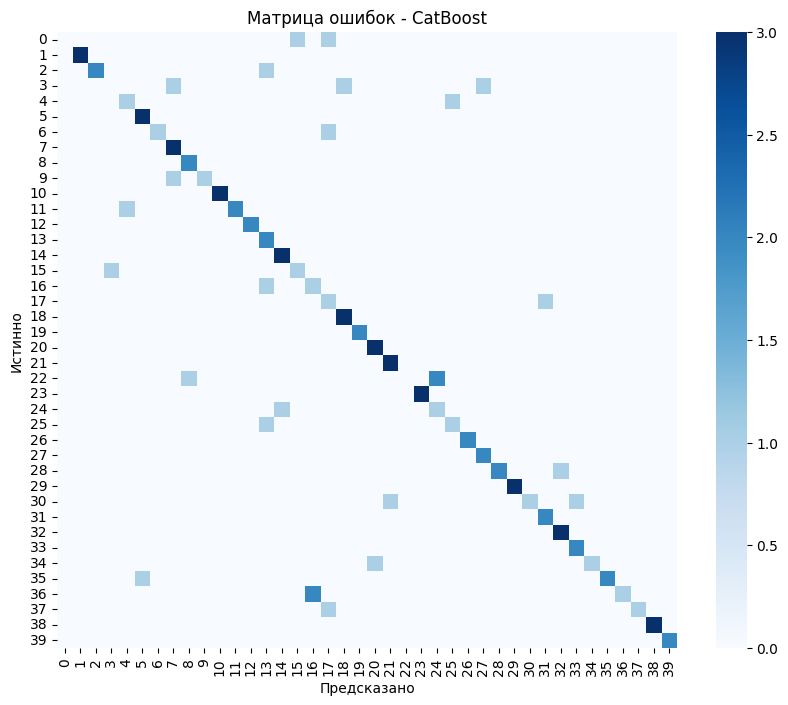


Модель: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 291931
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 4096
[LightGBM] [Info] Start training from score -3.624341
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score -3.624341
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score -3.624341
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score -3.624341
[LightGBM] [Info] Start training from score -3.624341
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score -3.757872
[LightGBM] [Info] Start training from score

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predict

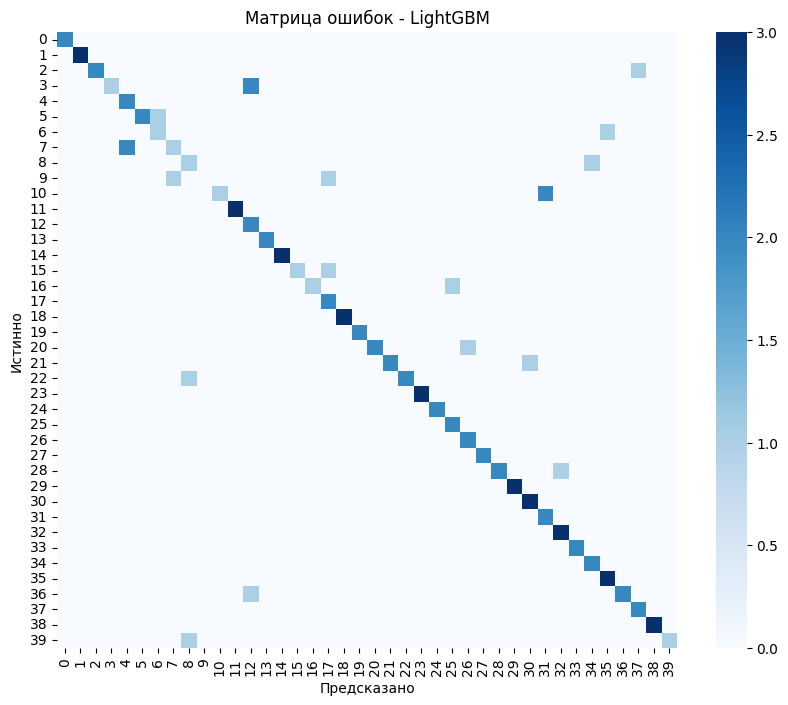


Модель: XGBoost
Accuracy: 0.7500
Время обучения: 47.99 сек

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3
           2       0.67      0.67      0.67         3
           3       1.00      0.33      0.50         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      0.50      0.67         2
           7       0.50      0.33      0.40         3
           8       0.40      1.00      0.57         2
           9       1.00      0.50      0.67         2
          10       0.50      0.33      0.40         3
          11       1.00      0.67      0.80         3
          12       0.33      0.50      0.40         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       0.50      0.50      0.50        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


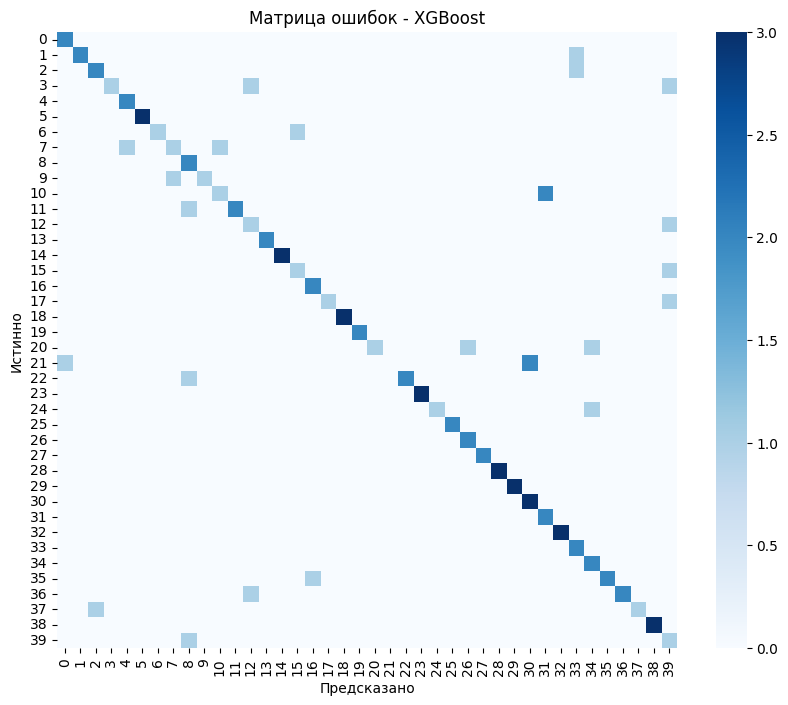


Модель: GradientBoosting
Accuracy: 0.5100
Время обучения: 321.91 сек

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.75      1.00      0.86         3
           2       0.00      0.00      0.00         3
           3       0.20      0.33      0.25         3
           4       0.00      0.00      0.00         2
           5       1.00      1.00      1.00         3
           6       1.00      0.50      0.67         2
           7       1.00      0.33      0.50         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.50      0.33      0.40         3
          11       1.00      0.67      0.80         3
          12       0.05      0.50      0.08         2
          13       0.00      0.00      0.00         2
          14       0.50      0.67      0.57         3
          15       0.50      0.50      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


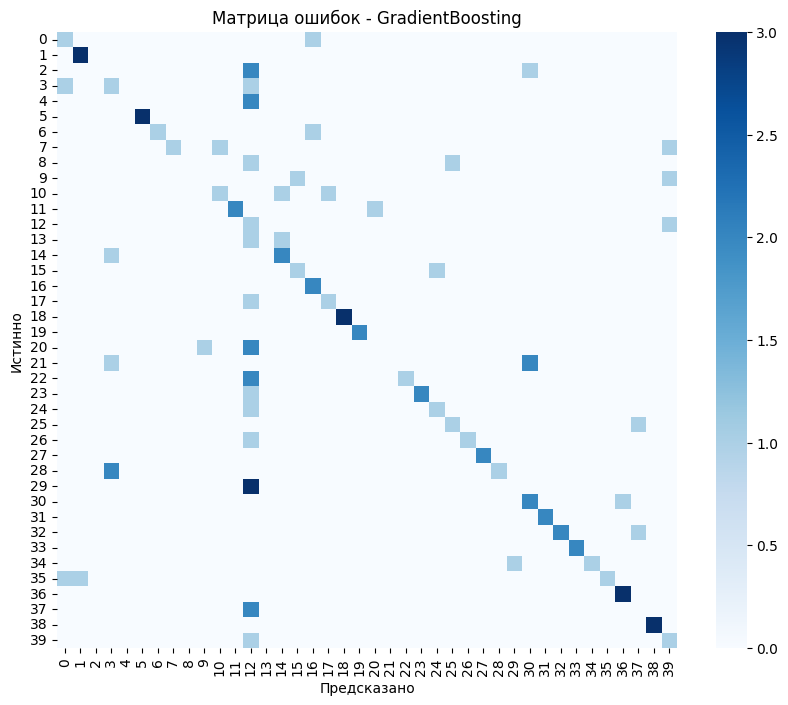

In [6]:
for name, model in models.items():

    print("\n" + "="*50)
    print(f"Модель: {name}")

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    train_time = end - start

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc, train_time])

    print(f"Accuracy: {acc:.4f}")
    print(f"Время обучения: {train_time:.2f} сек")

    # classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues")
    plt.title(f"Матрица ошибок - {name}")
    plt.xlabel("Предсказано")
    plt.ylabel("Истинно")
    plt.show()


ИТОГОВАЯ ТАБЛИЦА:
             Модель  Accuracy  Время обучения
0          CatBoost      0.74       87.372345
1          LightGBM      0.80       23.894120
2           XGBoost      0.75       47.988975
3  GradientBoosting      0.51      321.908180


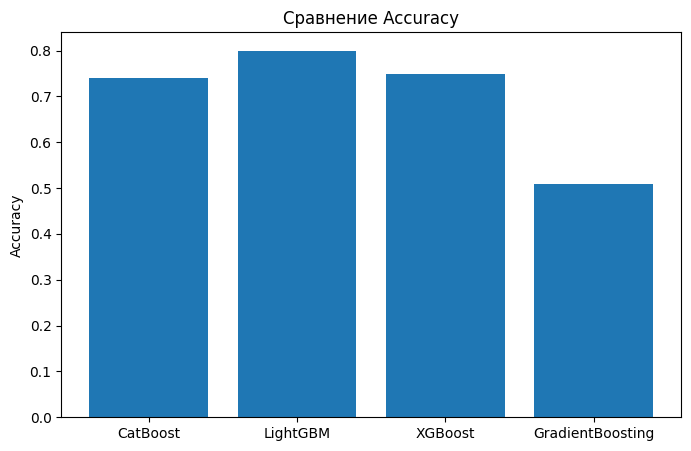

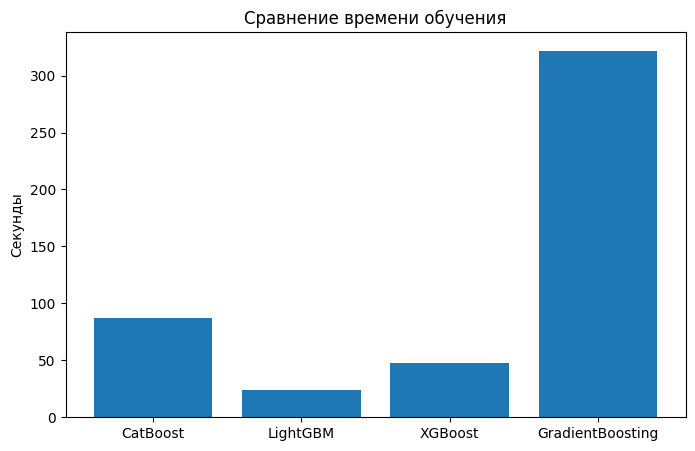

In [7]:
results_df = pd.DataFrame(
    results,
    columns=["Модель", "Accuracy", "Время обучения"]
)

print("\nИТОГОВАЯ ТАБЛИЦА:")
print(results_df)

# график точности
plt.figure(figsize=(8, 5))
plt.bar(results_df["Модель"], results_df["Accuracy"])
plt.title("Сравнение Accuracy")
plt.ylabel("Accuracy")
plt.show()

# график времени
plt.figure(figsize=(8, 5))
plt.bar(results_df["Модель"], results_df["Время обучения"])
plt.title("Сравнение времени обучения")
plt.ylabel("Секунды")
plt.show()

По результатам эксперимента наилучшую точность классификации показала модель LightGBM — 0.80, при этом она обучалась значительно быстрее большинства других алгоритмов. XGBoost и CatBoost также продемонстрировали хорошее качество распознавания лиц, однако время их обучения оказалось выше.

Классический GradientBoostingClassifier показал самую низкую точность (0.55) и самое длительное время обучения, что говорит о его меньшей эффективности по сравнению с современными реализациями градиентного бустинга.

Таким образом, для задачи классификации лиц наиболее эффективным алгоритмом оказался LightGBM, так как он обеспечивает хорошее соотношение точности и скорости обучения.

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

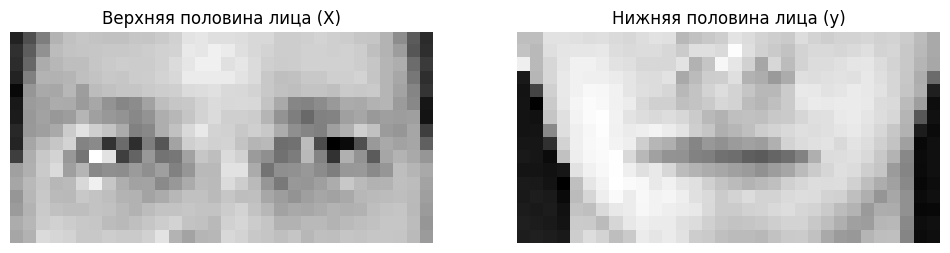

In [8]:
!pip install -q catboost lightgbm xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 1. Загрузка данных

faces = fetch_olivetti_faces()
images = faces.images

n_samples = images.shape[0]

# верхняя и нижняя половины
upper_half = images[:, :32, :]
lower_half = images[:, 32:, :]

# уменьшаем размерность для ускорения обучения
upper_half = upper_half[:, ::2, ::2]
lower_half = lower_half[:, ::2, ::2]

# пример для визуализации
upper_face = upper_half[0]
lower_face = lower_half[0]

# flatten
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [9]:
models = {

    "CatBoost": MultiOutputRegressor(
        CatBoostRegressor(
            iterations=15,
            depth=4,
            verbose=0
        )
    ),

    "LightGBM": MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=15,
            max_depth=4
        )
    ),

    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=15,
            max_depth=4,
            verbosity=0
        )
    ),

    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=10
        )
    )
}

results = []

In [10]:
for name, model in models.items():

    print("\n" + "="*50)
    print(f"Модель: {name}")

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    train_time = end - start

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    results.append([name, r2, train_time])

    print(f"R2 Score: {r2:.4f}")
    print(f"Время обучения: {train_time:.2f} сек")

Выходные данные были обрезаны до нескольких последних строк (5000).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003781 seconds.
You

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

R2 Score: 0.4785
Время обучения: 61.87 сек

Модель: XGBoost
R2 Score: 0.5225
Время обучения: 206.87 сек

Модель: GradientBoosting
R2 Score: 0.4029
Время обучения: 262.84 сек


In [11]:
results_df = pd.DataFrame(
    results,
    columns=["Модель", "R2", "Время"])

print(results_df)

             Модель        R2       Время
0          CatBoost  0.477471  238.481090
1          LightGBM  0.478473   61.873997
2           XGBoost  0.522469  206.867154
3  GradientBoosting  0.402877  262.838820


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

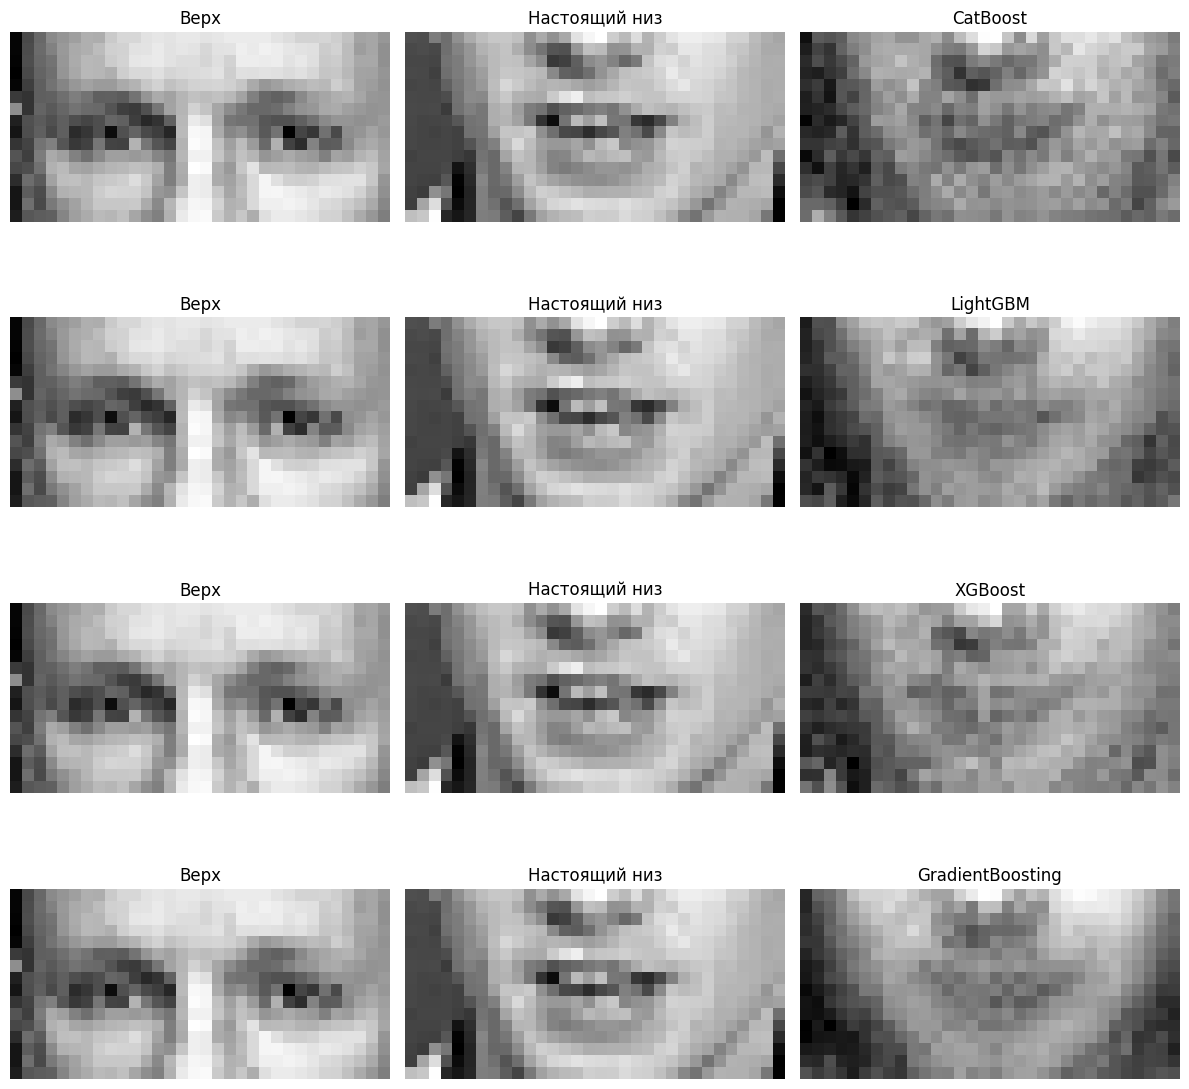

In [12]:
sample = 0

fig, axes = plt.subplots(len(models), 3, figsize=(12, 12))

for idx, (name, model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    upper = X_test[sample].reshape(16, 32)
    real = y_test[sample].reshape(16, 32)
    predicted = y_pred[sample].reshape(16, 32)

    # Верхняя часть
    axes[idx, 0].imshow(upper, cmap='gray')
    axes[idx, 0].set_title("Верх")
    axes[idx, 0].axis("off")

    # Настоящий низ
    axes[idx, 1].imshow(real, cmap='gray')
    axes[idx, 1].set_title("Настоящий низ")
    axes[idx, 1].axis("off")

    # Предсказанный низ
    axes[idx, 2].imshow(predicted, cmap='gray')
    axes[idx, 2].set_title(name)
    axes[idx, 2].axis("off")

plt.tight_layout()
plt.show()

По результатам эксперимента наилучшее качество восстановления нижней части лица показала модель XGBoost с коэффициентом R² = 0.522. CatBoost и LightGBM продемонстрировали близкие результаты качества, однако LightGBM обучался значительно быстрее остальных моделей.

GradientBoostingRegressor показал самое низкое значение R² и наибольшее время обучения, что свидетельствует о его меньшей эффективности для данной задачи по сравнению с современными реализациями градиентного бустинга.

Таким образом, XGBoost оказался наиболее точным алгоритмом для восстановления изображений, а LightGBM — самым быстрым по времени обучения.

## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования и может улучшить качество классификации, однако итоговый результат необходимо сравнить с качеством отдельных моделей.

- Мы будем использовать несколько классификаторов, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB, и объединим их в ансамбль с помощью VotingClassifier. Затем сравним метрики ансамбля с метриками отдельных базовых моделей и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

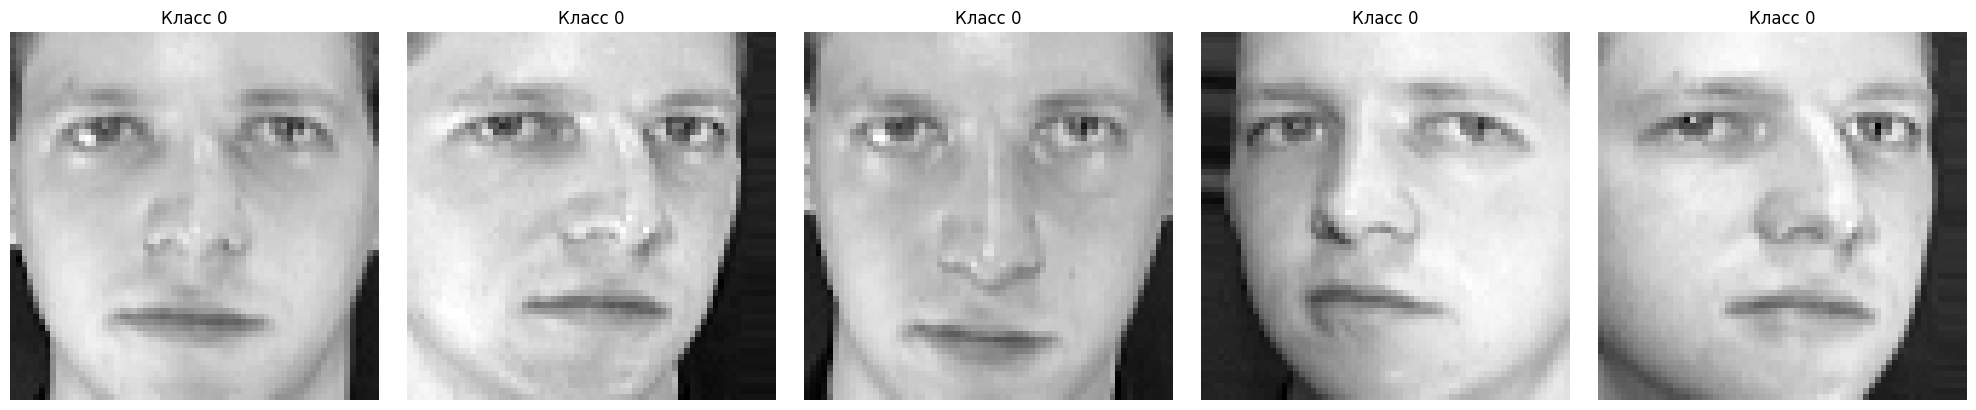

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import VotingClassifier

faces = fetch_olivetti_faces()

X = faces.images.reshape((faces.images.shape[0], -1))
y = faces.target

# нормализация
X = X / 255.0

# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = faces.images[i]
    label = faces.target[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
log_reg = LogisticRegression(max_iter=2000)
tree = DecisionTreeClassifier(max_depth=10)
knn = KNeighborsClassifier(n_neighbors=3)
gnb = GaussianNB()

voting = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('dt', tree),
        ('knn', knn),
        ('gnb', gnb)
    ],
    voting='hard')

models = {
    "LogisticRegression": log_reg,
    "DecisionTree": tree,
    "KNN": knn,
    "GaussianNB": gnb,
    "VotingClassifier": voting}


Модель: LogisticRegression
Accuracy: 0.2800
Precision macro: 0.2369
Recall macro: 0.3500
F1 macro: 0.2550
Precision weighted: 0.1895
Recall weighted: 0.2800
F1 weighted: 0.2040

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       1.00      0.50      0.67         2
           5       0.00      0.00      0.00         3
           6       0.40      1.00      0.57         2
           7       0.00      0.00      0.00         3
           8       0.25      0.50      0.33         2
           9       0.50      0.50      0.50         2
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       1.00      1.00      1.

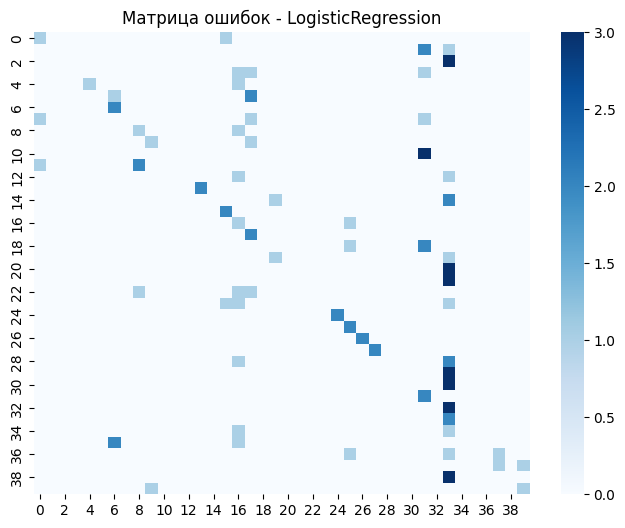


Модель: DecisionTree
Accuracy: 0.2800
Precision macro: 0.2861
Recall macro: 0.2792
F1 macro: 0.2628
Precision weighted: 0.2931
Recall weighted: 0.2800
F1 weighted: 0.2695

Classification Report:
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.33      0.50      0.40         2
          10       0.75      1.00      0.86         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00    

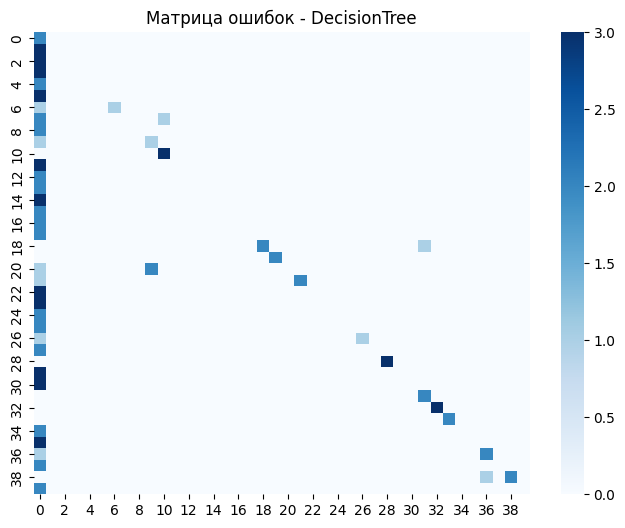


Модель: KNN
Accuracy: 0.9200
Precision macro: 0.9167
Recall macro: 0.9083
F1 macro: 0.9029
Precision weighted: 0.9283
Recall weighted: 0.9200
F1 weighted: 0.9154

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
  

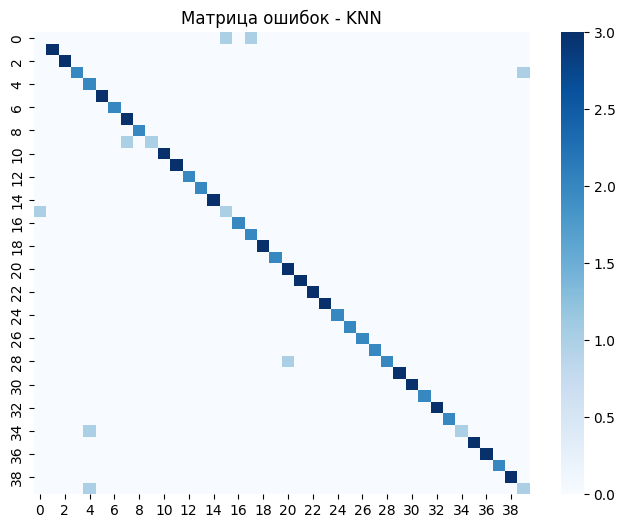


Модель: GaussianNB
Accuracy: 0.9200
Precision macro: 0.9483
Recall macro: 0.9167
F1 macro: 0.9113
Precision weighted: 0.9547
Recall weighted: 0.9200
F1 weighted: 0.9175

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.67      1.00      0.80         2
          13       1.00      0.50      0.67      

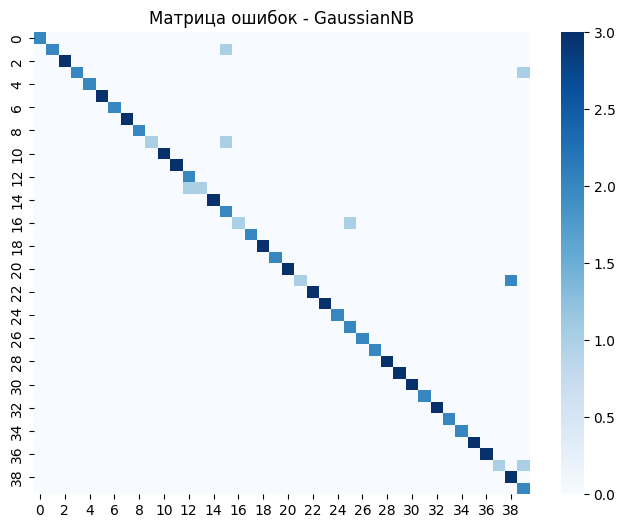


Модель: VotingClassifier
Accuracy: 0.8900
Precision macro: 0.9550
Recall macro: 0.8833
F1 macro: 0.8967
Precision weighted: 0.9640
Recall weighted: 0.8900
F1 weighted: 0.9073

Classification Report:
              precision    recall  f1-score   support

           0       0.20      1.00      0.33         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      0.67      0.80         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      0.67      0.80         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00

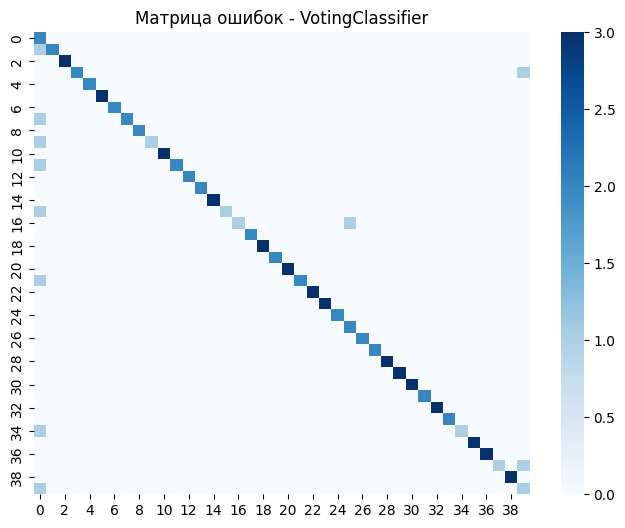


Сводная таблица метрик:


,Модель,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
0,LogisticRegression,0.28,0.236894,0.350000,0.254954,0.189515,0.28,0.203963
1,DecisionTree,0.28,0.286141,0.279167,0.262837,0.293080,0.28,0.269508
2,KNN,0.92,0.916667,0.908333,0.902857,0.928333,0.92,0.915429
3,GaussianNB,0.92,0.948333,0.916667,0.911250,0.954667,0.92,0.917500
4,VotingClassifier,0.89,0.955000,0.883333,0.896667,0.964000,0.89,0.907333


In [15]:
results = []

for name, model in models.items():

    print("\n" + "="*50)
    print(f"Модель: {name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        "Модель": name,
        "Accuracy": acc,
        "Precision macro": precision_macro,
        "Recall macro": recall_macro,
        "F1 macro": f1_macro,
        "Precision weighted": precision_weighted,
        "Recall weighted": recall_weighted,
        "F1 weighted": f1_weighted
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision macro: {precision_macro:.4f}")
    print(f"Recall macro: {recall_macro:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"Precision weighted: {precision_weighted:.4f}")
    print(f"Recall weighted: {recall_weighted:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, cmap="Blues")
    plt.title(f"Матрица ошибок - {name}")
    plt.show()

results_df = pd.DataFrame(results)
print("\nСводная таблица метрик:")
display(results_df)

В ходе работы были исследованы отдельные классификаторы LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB, а также ансамблевый метод VotingClassifier для задачи распознавания лиц из набора данных Olivetti Faces.

Для оценки качества использовались несколько метрик: accuracy, precision, recall и F1-score. Дополнительно анализировались macro average и weighted average, так как они позволяют оценить качество модели не только по общей доле правильных ответов, но и по качеству распознавания отдельных классов.

Результаты показали, что наилучшее качество среди отдельных моделей продемонстрировали KNeighborsClassifier и GaussianNB: accuracy = 0.92. У KNeighborsClassifier weighted F1-score составил 0.92, а у GaussianNB weighted F1-score также составил 0.92. LogisticRegression и DecisionTreeClassifier показали значительно более низкую точность — около 0.28.

VotingClassifier показал accuracy = 0.89, weighted precision = 0.96, weighted recall = 0.89 и weighted F1-score = 0.91. Несмотря на достаточно высокие значения метрик, ансамбль оказался хуже лучших отдельных моделей KNeighborsClassifier и GaussianNB по accuracy и weighted F1-score. Это означает, что в данном эксперименте простое жесткое голосование не улучшило результат, потому что в ансамбль вместе с сильными моделями вошли слабые классификаторы LogisticRegression и DecisionTreeClassifier.

Таким образом, для данной задачи наиболее эффективными оказались KNeighborsClassifier и GaussianNB, а VotingClassifier не дал прироста качества по сравнению с лучшими отдельными моделями.

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах. Итоговое качество необходимо сравнить с качеством отдельных базовых моделей.


- Мы будем использовать несколько классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем обучим метаклассификатор второго уровня LogisticRegression на выходах классификаторов первого уровня и сравним его метрики с метриками отдельных моделей.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

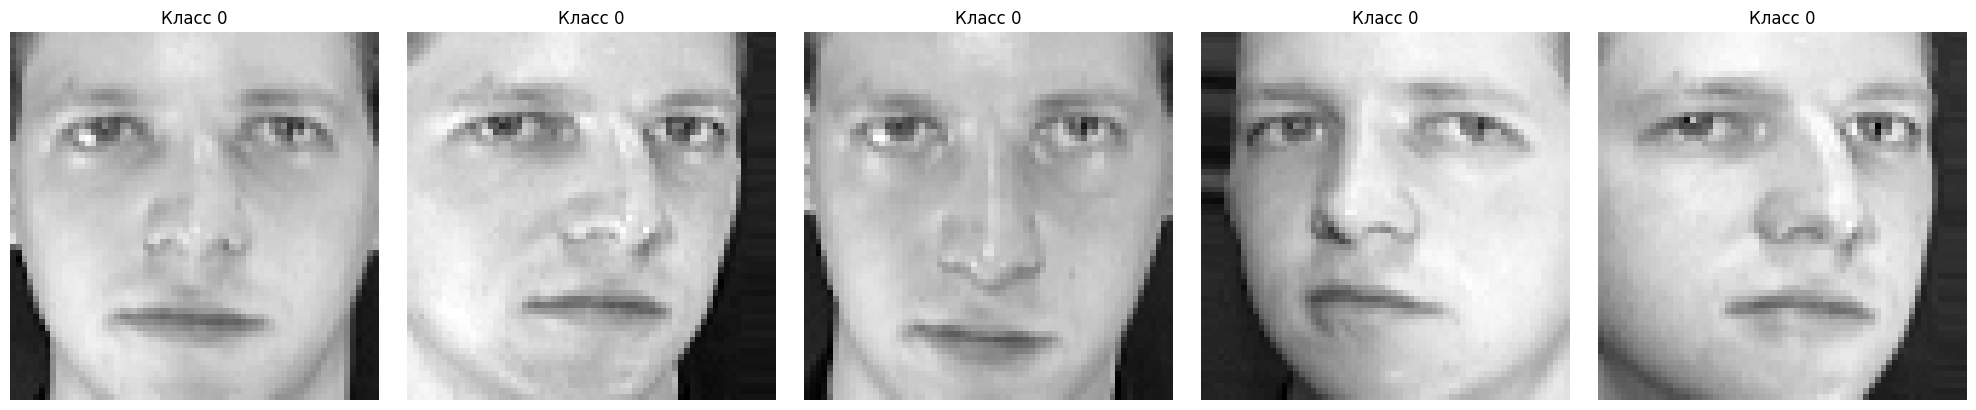

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import StackingClassifier

faces = fetch_olivetti_faces()

X = faces.images.reshape((faces.images.shape[0], -1))
y = faces.target

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = faces.images[i]
    label = faces.target[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
log_reg = LogisticRegression(max_iter=2000)
tree = DecisionTreeClassifier(max_depth=10)
knn = KNeighborsClassifier(n_neighbors=3)
gnb = GaussianNB()

estimators = [
    ('lr', log_reg),
    ('dt', tree),
    ('knn', knn),
    ('gnb', gnb)]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000))

models = {
    "LogisticRegression": log_reg,
    "DecisionTree": tree,
    "KNN": knn,
    "GaussianNB": gnb,
    "StackingClassifier": stacking
}


Модель: LogisticRegression
Accuracy: 0.2800
Precision macro: 0.2369
Recall macro: 0.3500
F1 macro: 0.2550
Precision weighted: 0.1895
Recall weighted: 0.2800
F1 weighted: 0.2040

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       1.00      0.50      0.67         2
           5       0.00      0.00      0.00         3
           6       0.40      1.00      0.57         2
           7       0.00      0.00      0.00         3
           8       0.25      0.50      0.33         2
           9       0.50      0.50      0.50         2
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       1.00      1.00      1.

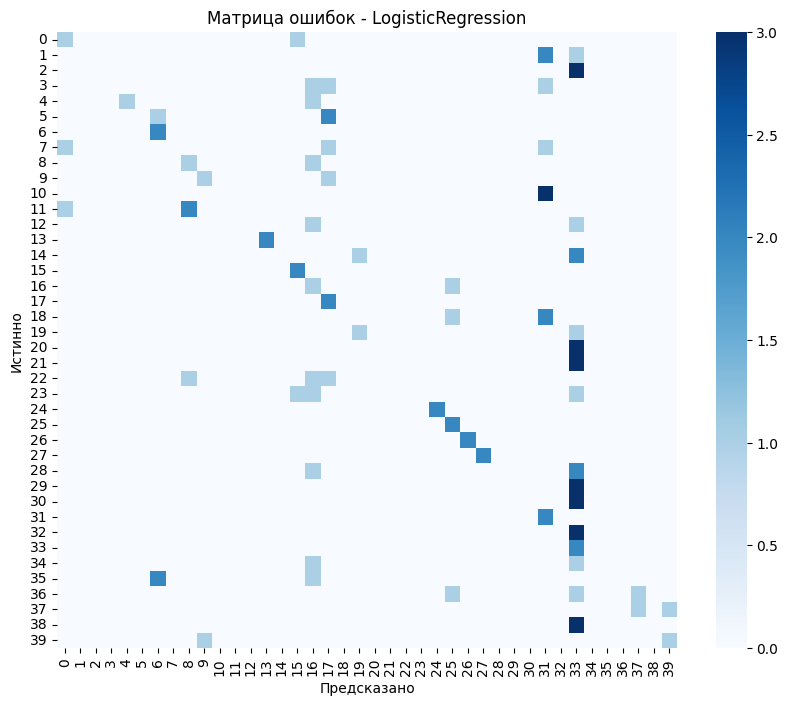


Модель: DecisionTree
Accuracy: 0.2400
Precision macro: 0.2632
Recall macro: 0.2458
F1 macro: 0.2269
Precision weighted: 0.2682
Recall weighted: 0.2400
F1 weighted: 0.2287

Classification Report:
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.33      0.50      0.40         2
          10       0.50      0.33      0.40         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00    

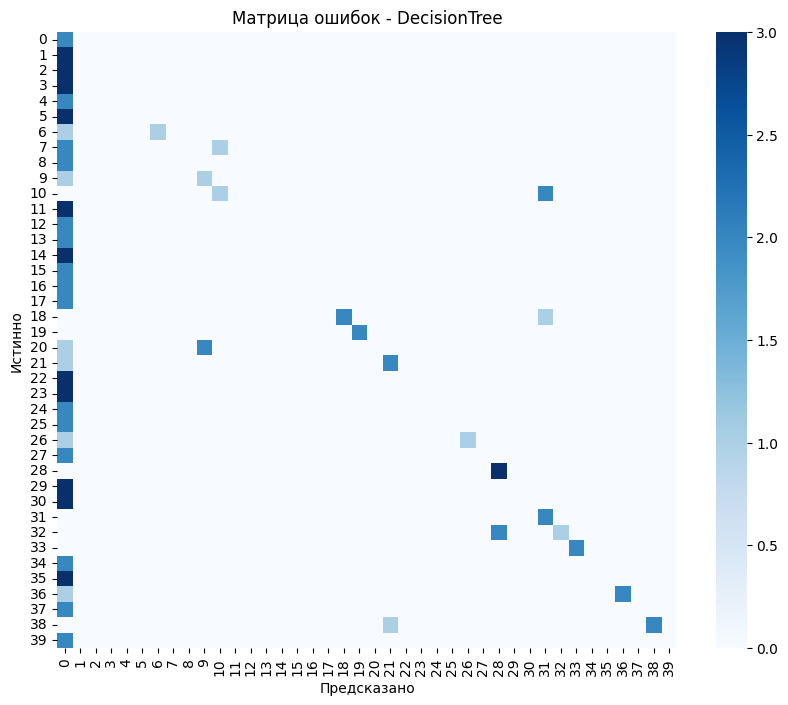


Модель: KNN
Accuracy: 0.9200
Precision macro: 0.9167
Recall macro: 0.9083
F1 macro: 0.9029
Precision weighted: 0.9283
Recall weighted: 0.9200
F1 weighted: 0.9154

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
  

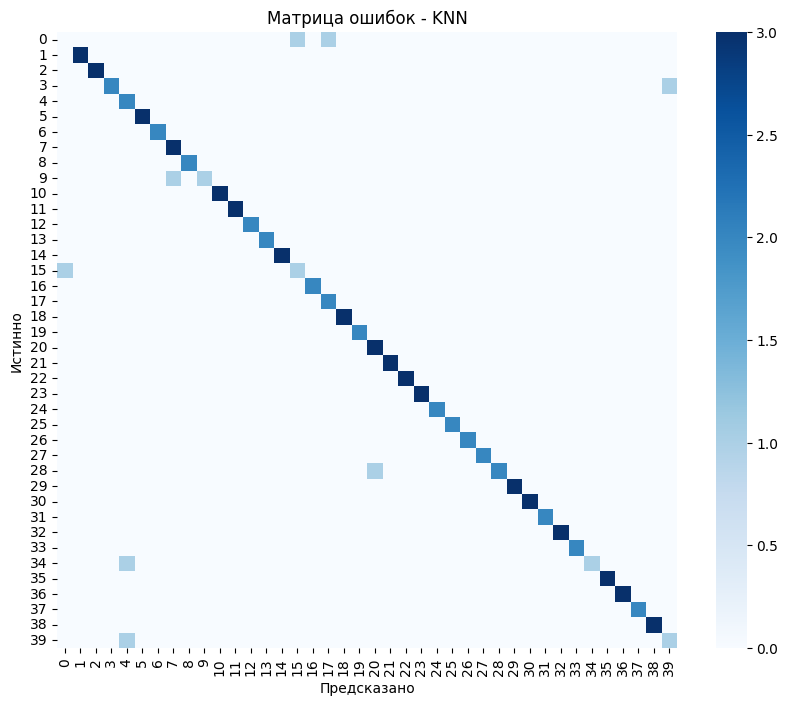


Модель: GaussianNB
Accuracy: 0.9200
Precision macro: 0.9483
Recall macro: 0.9167
F1 macro: 0.9113
Precision weighted: 0.9547
Recall weighted: 0.9200
F1 weighted: 0.9175

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.67      1.00      0.80         2
          13       1.00      0.50      0.67      

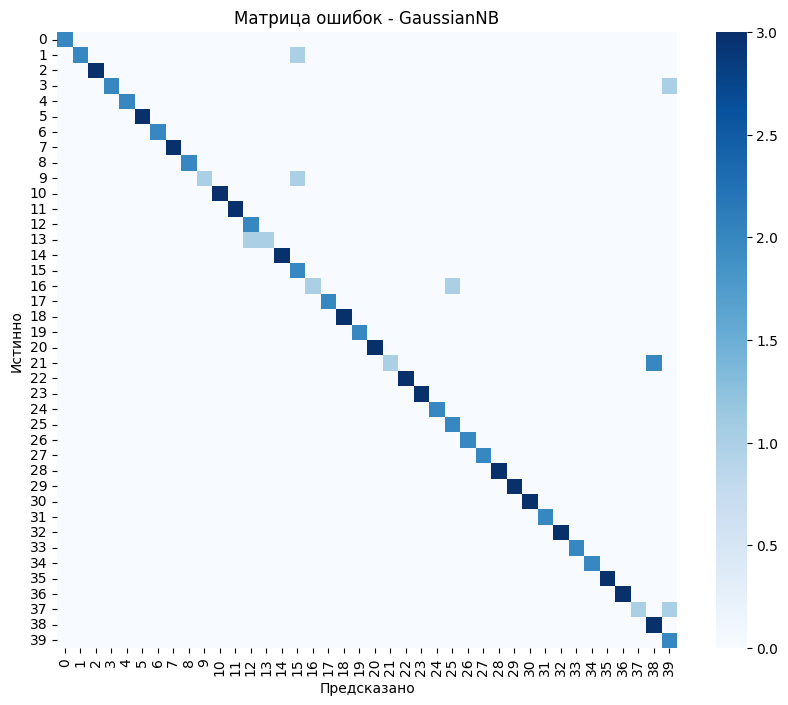


Модель: StackingClassifier
Accuracy: 0.9500
Precision macro: 0.9646
Recall macro: 0.9458
F1 macro: 0.9431
Precision weighted: 0.9692
Recall weighted: 0.9500
F1 weighted: 0.9490

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.

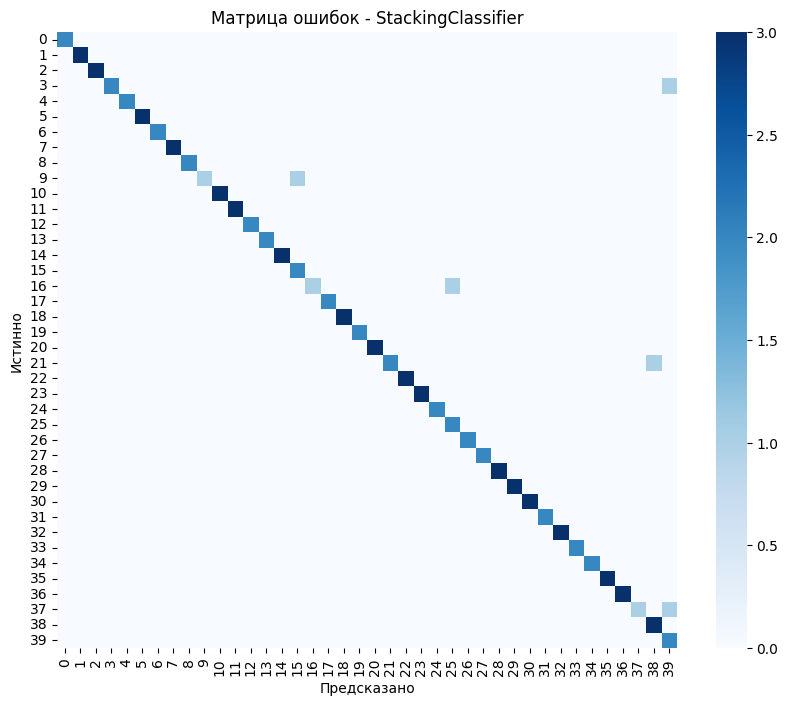


Сводная таблица метрик:


,Модель,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
0,LogisticRegression,0.28,0.236894,0.350000,0.254954,0.189515,0.28,0.203963
1,DecisionTree,0.24,0.263225,0.245833,0.226944,0.268246,0.24,0.228722
2,KNN,0.92,0.916667,0.908333,0.902857,0.928333,0.92,0.915429
3,GaussianNB,0.92,0.948333,0.916667,0.911250,0.954667,0.92,0.917500
4,StackingClassifier,0.95,0.964583,0.945833,0.943095,0.969167,0.95,0.949048


In [18]:
results = []

for name, model in models.items():

    print("\n" + "="*50)
    print(f"Модель: {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        "Модель": name,
        "Accuracy": acc,
        "Precision macro": precision_macro,
        "Recall macro": recall_macro,
        "F1 macro": f1_macro,
        "Precision weighted": precision_weighted,
        "Recall weighted": recall_weighted,
        "F1 weighted": f1_weighted
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision macro: {precision_macro:.4f}")
    print(f"Recall macro: {recall_macro:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"Precision weighted: {precision_weighted:.4f}")
    print(f"Recall weighted: {recall_weighted:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues")
    plt.title(f"Матрица ошибок - {name}")
    plt.xlabel("Предсказано")
    plt.ylabel("Истинно")
    plt.show()

results_df = pd.DataFrame(results)
print("\nСводная таблица метрик:")
display(results_df)

В ходе работы был исследован ансамблевый метод StackingClassifier для задачи классификации лиц из набора данных Olivetti Faces.

В качестве базовых моделей были использованы LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB, а в роли метаклассификатора применялась LogisticRegression. Перед обучением изображения были преобразованы в векторы признаков и нормализованы.

Для оценки качества использовались accuracy, precision, recall и F1-score, а также macro average и weighted average. Эти метрики позволяют сравнить модели не только по общей доле правильных ответов, но и по качеству распознавания классов.

По результатам эксперимента StackingClassifier показал accuracy = 0.95, weighted precision = 0.97, weighted recall = 0.95 и weighted F1-score = 0.95. Это выше результатов отдельных моделей KNeighborsClassifier и GaussianNB, у которых accuracy = 0.92 и weighted F1-score = 0.92. LogisticRegression и DecisionTreeClassifier показали заметно более слабые результаты.

Таким образом, в данном эксперименте StackingClassifier действительно улучшил качество классификации по сравнению с отдельными базовыми моделями. В отличие от VotingClassifier, stacking использует метаклассификатор, который обучается комбинировать ответы базовых моделей, поэтому в этой задаче он оказался эффективнее простого голосования.